In [2]:
import os
import random
from shutil import copyfile
import tensorflow as tf
# from dnn_app_utils_v3 import *
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from matplotlib.pyplot import *
import matplotlib.pyplot as plt
import tensorflow as tf
import PIL
from PIL import Image
from numpy import asarray
from keras.preprocessing import image
from keras.preprocessing.image import ImageDataGenerator
from IPython.display import Image, display
from tensorflow.keras.optimizers import RMSprop
from io import BytesIO
import io

#### Add images to "python_data/fruits/data original"and name all the images of the file the name of the fruit
##### Add that name of fruit to fruit_name, and it will create the training and testing files for you

In [1]:
fruit_name = 'banana'

SOURCE = 'A:/python_data/fruits/data original/' + fruit_name +'/'

listdir = os.listdir(SOURCE)
list_of_filenames = []
i = 0
print('Original Number of files in directory: {}'.format(len(listdir)))

for file_name in listdir:
    file_path = SOURCE + file_name
    
    #size should be greater than atleast 4kb
    if os.path.getsize(file_path)/1024 > 4:
        list_of_filenames.append(file_name)
        
    else: 
        i += 1
#         print('skipped')
#         print(os.path.getsize(file_path))
        
print('Number of files skipped: {}'.format(i))

#splitting data randomly into 90% train and 10% validation
n = len(list_of_files)
split_point = int(n * 0.9)
shuffled = random.sample(list_of_files, n)

train = list_of_filenames[:split_point]
test = list_of_filenames[split_point:]

#Creating Directories for training and testing
try: 
    os.mkdir('A:/python_data/fruits/data formatted/training/' + fruit_name)
    os.mkdir('A:/python_data/fruits/data formatted/testing/' + fruit_name)
    
except: print('Training Directory already created called ', fruit_name)

# adding files to training and testing directories
try:
    TRAINING = 'A:/python_data/fruits/data formatted/training/'+ fruit_name + '/'
    
    for file_name in train:
            copyfile(SOURCE + file_name, TRAINING + file_name)
    
    TESTING = 'A:/python_data/fruits/data formatted/testing/'+ fruit_name + '/'
    for file_name in test:
        copyfile(SOURCE + file_name, TESTING + file_name)
            
except:
    print('files already copied to "data formatted"')  
    


NameError: name 'os' is not defined

#### This cell removes the images which the io.bytes object cannot read. 

In [259]:

main_dir = 'A:/python_data/fruits/data formatted/'
number_of_fruits = os.listdir(main_dir + 'training/')

#Going into training and testing
for file in os.listdir(main_dir): 
    temp_dir1 = main_dir + file + '/'
    
    #getting into each fruit_file of training and testing
    for fruit in os.listdir(temp_dir1):
        temp_dir2 = main_dir + file + '/' + fruit + '/'
        
        #going into each fruit_file of training and testing
        for file_name in os.listdir(temp_dir2):
            file_directory = temp_dir2 + file_name
            
            try: 
                byteImgIO = io.BytesIO()
                byteImg = Image.open(file_directory)
                
            except:
                print('Deleted this directory: {}'.format(file_directory))
                os.remove(file_directory)

Deleted this directory: A:/python_data/fruits/data formatted/testing/banana/_cdbf52fa-5a63-11e8-b431-73159b4b09e2.jpg
Deleted this directory: A:/python_data/fruits/data formatted/training/banana/banana-625_625x350_41459935133.jpg
Deleted this directory: A:/python_data/fruits/data formatted/training/banana/bananas__96344.1290309370.gif
Deleted this directory: A:/python_data/fruits/data formatted/training/banana/banana_625x350_71441851563.jpg
Deleted this directory: A:/python_data/fruits/data formatted/training/banana/c209a66113d145ca90c4363bd32d685f.jpg
Deleted this directory: A:/python_data/fruits/data formatted/training/banana/dl9g6gn8_bananas_625x300_11_April_19.jpg


## Creating Tensorflow Model

In [265]:
model = tf.keras.models.Sequential([
    tf.keras.layers.Conv2D(16, (3,3),  activation='relu', input_shape=(300,300,3)),
    tf.keras.layers.MaxPooling2D(2,2),
    
    tf.keras.layers.Conv2D(32, (3,3),  activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),
    
    tf.keras.layers.Conv2D(64, (3,3),  activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),
    
    tf.keras.layers.Conv2D(64, (3,3),  activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),
    
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(512, activation = 'relu'),
    tf.keras.layers.Dense(4, activation = 'softmax')
])

model.compile(loss = 'categorical_crossentropy',
             optimizer = 'adam', #RMSprop(lr = 0.001),
             metrics = ['accuracy']
             )
train_datagen = ImageDataGenerator(
    rescale = 1/255,
    rotation_range = 40,
    width_shift_range = 0.2,
    shear_range = 0.2,
    zoom_range =0.2,
    horizontal_flip = True,
    fill_mode = 'nearest'
    ) #normalizing data
train_generator = train_datagen.flow_from_directory(
        'A:/python_data/fruits/data formatted/training/',  # This is the source directory for training images
        target_size=(300, 300),  # All images will be resized to 150x150
        batch_size=40,
        # Since we use binary_crossentropy loss, we need binary labels
        class_mode="categorical")

validation_datagen = ImageDataGenerator(
    rescale=1 / 255,
)


validation_generator = validation_datagen.flow_from_directory(
    'A:/python_data/fruits/data formatted/testing/',
    batch_size=40,
    class_mode='categorical',
    target_size=(300, 300)
)

Found 440 images belonging to 4 classes.
Found 171 images belonging to 4 classes.


In [276]:
final_model  = model.fit(
    train_generator,
    steps_per_epoch =11,
    epochs = 3,
    verbose = 1,
    validation_data=validation_generator
)

Epoch 1/3
 6/11 [===============>..............] - ETA: 26s - loss: 0.3675 - accuracy: 0.8625

C:\Users\91762\anaconda3\lib\site-packages\PIL\TiffImagePlugin.py:788: UserWarning: Corrupt EXIF data.  Expecting to read 4 bytes but only got 0. 
  warnings.warn(str(msg))


11/11 [==============================] - ETA: 0s - loss: 0.3820 - accuracy: 0.8500

C:\Users\91762\anaconda3\lib\site-packages\PIL\Image.py:932: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  "Palette images with Transparency expressed in bytes should be "


11/11 [==============================] - 69s 6s/step - loss: 0.3820 - accuracy: 0.8500 - val_loss: 0.8318 - val_accuracy: 0.6140
Epoch 2/3
11/11 [==============================] - 67s 6s/step - loss: 0.4551 - accuracy: 0.7864 - val_loss: 0.8664 - val_accuracy: 0.6491
Epoch 3/3
11/11 [==============================] - 67s 6s/step - loss: 0.4570 - accuracy: 0.8114 - val_loss: 0.5713 - val_accuracy: 0.7836


In [283]:
def predictor(img_dir):
    img = image.load_img(img_dir, target_size = (300,300))
    x = image.img_to_array(img)
    x = np.expand_dims(x, axis = 0) #increases the dimension of the array by one. if 1D, becomes 2D.
                                    #axis = 0 ==> shape = (1, length)
                                    #here, it changes shape from (300, 300, 3) to (1,300,300,3)
    images = np.vstack([x]) #stacks the array vertically (the shape does not change for some reason)
    classes = model.predict(images, batch_size = 10)

    print('The class of the image is ', np.squeeze(classes[0]))
    
    classes = np.squeeze(classes[0])
    
predictor('A:/python_data/fruits/data formatted/training/banana/image28.jpeg')

The class of the image is  [0. 0. 1. 0.]


dict_keys(['loss', 'accuracy', 'val_loss', 'val_accuracy'])


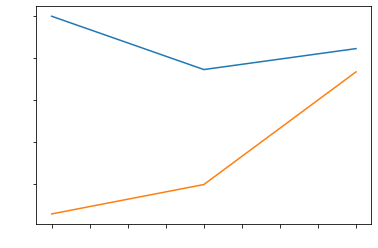

In [277]:
print(final_model.history.keys())

accuracy = final_model.history['accuracy']
val_accuracy = final_model.history['val_accuracy']

plt.figure()
plt.plot(accuracy)
plt.plot(val_accuracy)
plt.xticks(color = 'white')
plt.yticks(color = 'white');


